

This project analyzes hospital encounter data from diabetic patients to identify factors associated with 30-day readmission and build predictive models for readmission risk. The workflow includes data cleaning, exploratory data analysis, feature encoding, logistic regression, random forest modeling, hyperparameter tuning, threshold adjustment, and model interpretation.

# Project Overview

Hospital readmission is an important healthcare quality and cost issue. Patients who are readmitted shortly after discharge may have more complex health conditions, insufficient follow-up care, or unmet care needs. In this project, I analyzed a hospital encounter dataset of diabetic patients to study factors associated with 30-day readmission.

The main goal of this project was to identify patterns related to 30-day hospital readmission and build predictive models to estimate whether a patient would be readmitted within 30 days. The outcome variable was converted into a binary indicator, where `readmitted_30 = 1` means the patient was readmitted within 30 days and `readmitted_30 = 0` means the patient was not readmitted within 30 days.

This project followed a complete machine learning workflow, including data cleaning, missing value handling, exploratory data analysis, feature encoding, model training, hyperparameter tuning, threshold adjustment, and model interpretation. Logistic Regression was used as a baseline model, and Random Forest models were used to capture more complex relationships among predictors.

Because only about 11% of encounters resulted in 30-day readmission, this was an imbalanced classification problem. Therefore, model performance was evaluated using metrics such as precision, recall, F1-score, and ROC-AUC instead of relying only on accuracy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#  Read data
df = pd.read_csv("E:/Pycharm/program/1/data/diabetic_data.csv")

In [ ]:
#  Basic information
print("Dataset shape:")
print(df.shape)

print("\nHEAD:")
print(df.head())

print("\nColumn name:")
print(df.columns.tolist())

print("\nSummary statistics:")
print(df.describe())


Dataset shape:
(101766, 50)

HEAD:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...      

#  Data Cleaning

In [ ]:
#  Check missing values represented by "?"
missing_question = (df == "?").sum().sort_values(ascending=False)

print("\nMissing values represented by ?:")
print(missing_question[missing_question > 0])


Missing values represented by ?:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [5]:

df = df.replace("?", np.nan)

print("\nMissing values after replacing ?:")
print(df.isna().sum().sort_values(ascending=False).head(20))


Missing values after replacing ?:
weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
dtype: int64


In [ ]:
#  Create binary outcome variable
df["readmitted_30"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

print("\nOriginal readmitted distribution:")
print(df["readmitted"].value_counts())

print("\nBinary readmitted_30 distribution:")
print(df["readmitted_30"].value_counts())
print(df["readmitted_30"].value_counts(normalize=True))


Original readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary readmitted_30 distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64
readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [7]:
# Check missing percentage
missing_percent = df.isna().mean().sort_values(ascending=False) * 100

print("Missing percentage:")
print(missing_percent[missing_percent > 0])

Missing percentage:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [8]:
cols_to_drop = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df_clean = df.drop(columns=cols_to_drop)

print("Shape after dropping high-missing columns:")
print(df_clean.shape)

Shape after dropping high-missing columns:
(101766, 46)


These variables were removed because they had a high proportion of missing values.

In [9]:
df_clean = df_clean.dropna()

print("Shape after dropping rows with remaining missing values:")
print(df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

Shape after dropping rows with remaining missing values:
(98053, 46)

Remaining missing values:
encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
dtype: int64


In [10]:
print("Readmitted 30-day distribution after cleaning:")
print(df_clean["readmitted_30"].value_counts())
print(df_clean["readmitted_30"].value_counts(normalize=True))

Readmitted 30-day distribution after cleaning:
readmitted_30
0    86987
1    11066
Name: count, dtype: int64
readmitted_30
0    0.887143
1    0.112857
Name: proportion, dtype: float64


#  Exploratory Data Analysis

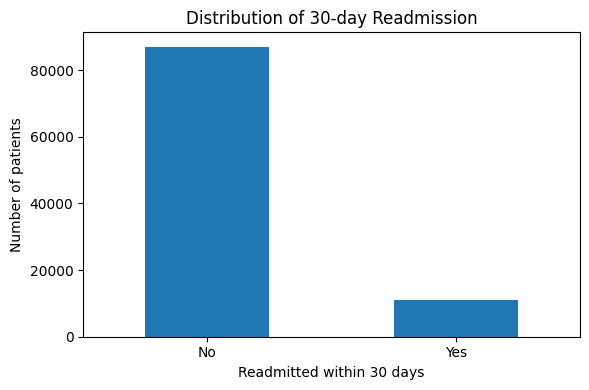

In [11]:

readmit_counts = df_clean["readmitted_30"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
readmit_counts.plot(kind="bar")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of patients")
plt.title("Distribution of 30-day Readmission")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

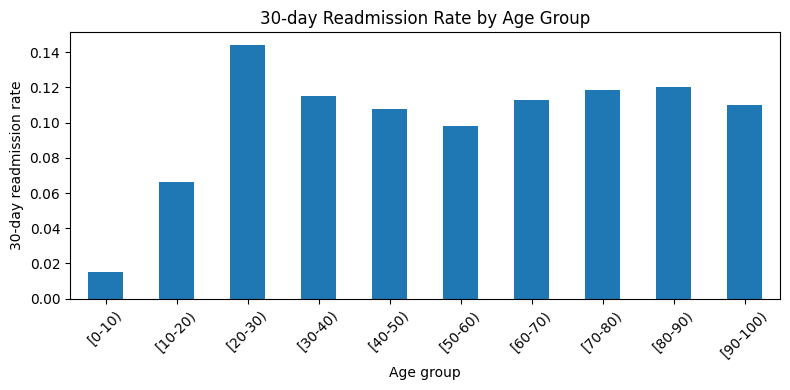

age
[0-10)      0.015385
[10-20)     0.066524
[20-30)     0.144114
[30-40)     0.114994
[40-50)     0.107933
[50-60)     0.098101
[60-70)     0.112797
[70-80)     0.118707
[80-90)     0.120465
[90-100)    0.110048
Name: readmitted_30, dtype: float64


In [12]:
readmit_by_age = df_clean.groupby("age")["readmitted_30"].mean()

plt.figure(figsize=(8, 4))
readmit_by_age.plot(kind="bar")
plt.xlabel("Age group")
plt.ylabel("30-day readmission rate")
plt.title("30-day Readmission Rate by Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(readmit_by_age)

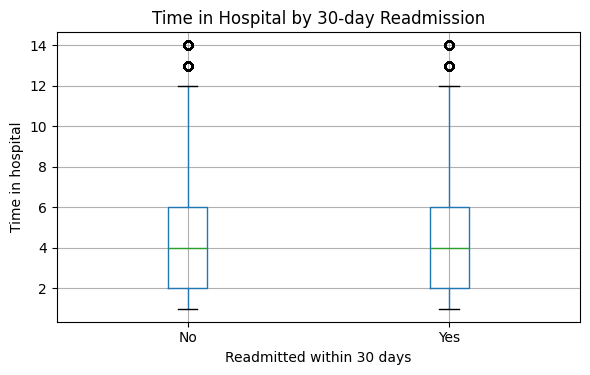

In [37]:
ax = df_clean.boxplot(column="time_in_hospital", by="readmitted_30", figsize=(6, 4))
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Time in hospital")
plt.title("Time in Hospital by 30-day Readmission")
plt.suptitle("")
plt.xticks([1, 2], ["No", "Yes"])
plt.tight_layout()
plt.show()

Were the patients who were readmitted within 30 days already in hospital for a longer period of time before?

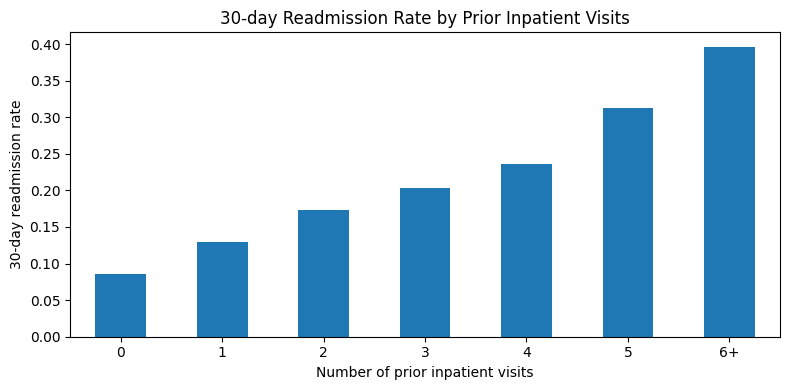

inpatient_group
0     0.085450
1     0.129805
2     0.173427
3     0.203825
4     0.236694
5     0.312968
6+    0.396290
Name: readmitted_30, dtype: float64


In [14]:
# Create grouped inpatient visit variable
df_clean["inpatient_group"] = df_clean["number_inpatient"].apply(
    lambda x: "6+" if x >= 6 else str(x)
)

# Set category order
inpatient_order = ["0", "1", "2", "3", "4", "5", "6+"]
df_clean["inpatient_group"] = pd.Categorical(
    df_clean["inpatient_group"],
    categories=inpatient_order,
    ordered=True
)

# Calculate readmission rate by grouped inpatient visits
readmit_by_inpatient_group = df_clean.groupby(
    "inpatient_group",
    observed=False
)["readmitted_30"].mean()

# Plot
plt.figure(figsize=(8, 4))
readmit_by_inpatient_group.plot(kind="bar")
plt.xlabel("Number of prior inpatient visits")
plt.ylabel("30-day readmission rate")
plt.title("30-day Readmission Rate by Prior Inpatient Visits")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(readmit_by_inpatient_group)

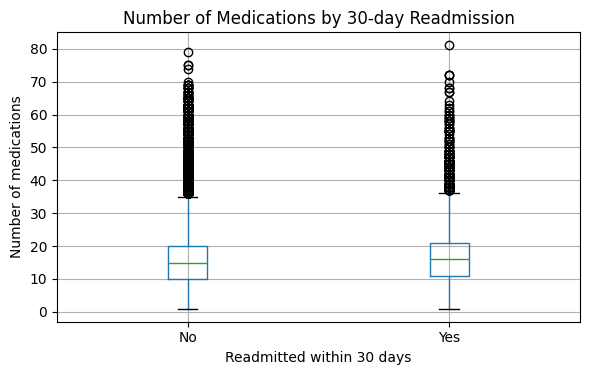

In [36]:
ax = df_clean.boxplot(column="num_medications", by="readmitted_30", figsize=(6, 4))
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of medications")
plt.title("Number of Medications by 30-day Readmission")
plt.suptitle("")
plt.xticks([1, 2], ["No", "Yes"])
plt.tight_layout()
plt.show()

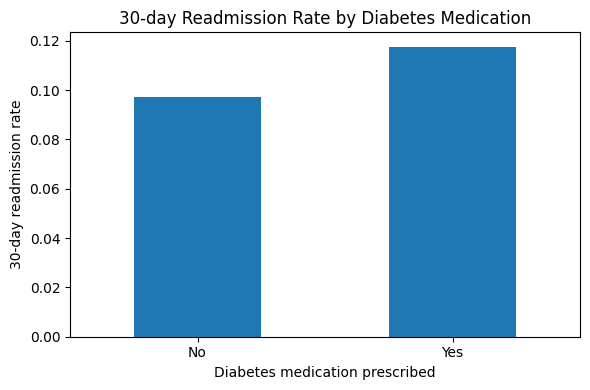

diabetesMed
No     0.097260
Yes    0.117557
Name: readmitted_30, dtype: float64


In [16]:
readmit_by_diabetesMed = df_clean.groupby("diabetesMed")["readmitted_30"].mean()

plt.figure(figsize=(6, 4))
readmit_by_diabetesMed.plot(kind="bar")
plt.xlabel("Diabetes medication prescribed")
plt.ylabel("30-day readmission rate")
plt.title("30-day Readmission Rate by Diabetes Medication")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(readmit_by_diabetesMed)

# EDA Findings

The cleaned dataset contained 98,053 encounters and 46 variables. The binary outcome variable `readmitted_30` was created to indicate whether a patient was readmitted within 30 days. Only 11.29% of encounters resulted in 30-day readmission, suggesting a clear class imbalance problem.

The age-group analysis showed that younger patients had lower 30-day readmission rates, while adult and older age groups generally had higher rates. However, the pattern was not strictly linear across age groups.

The boxplot of time in hospital showed similar distributions between patients with and without 30-day readmission, suggesting that length of stay alone may not strongly distinguish readmitted patients.

Prior inpatient utilization appeared to be strongly associated with 30-day readmission. Patients with more previous inpatient visits had higher readmission rates, indicating that recent hospital use may be an important predictor of future readmission risk.

The boxplot of the number of medications showed that patients readmitted within 30 days had a slightly higher median number of medications than those who were not readmitted. This suggests that medication burden may be associated with readmission risk, possibly reflecting greater clinical complexity.

Patients who were prescribed diabetes medication also had a higher 30-day readmission rate than those who were not. However, this relationship should not be interpreted as causal. Diabetes medication use may be a marker of more severe diabetes or more complex disease management.

1. 30-day readmission rate was about 11.3%, showing class imbalance.
2. Patients with more prior inpatient visits had higher readmission rates.
3. Patients prescribed diabetes medication had higher readmission rates.
4. Patients readmitted within 30 days had slightly more medications on average.
5. Time in hospital alone did not clearly separate readmitted and non-readmitted patients.

#  Baseline Model: Logistic Regression

In [17]:
features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "diabetesMed",
    "insulin"
]

X = df_clean[features]
y = df_clean["readmitted_30"]

In [18]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[11976  5422]
 [ 1136  1077]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.69      0.79     17398
           1       0.17      0.49      0.25      2213

    accuracy                           0.67     19611
   macro avg       0.54      0.59      0.52     19611
weighted avg       0.83      0.67      0.72     19611


ROC-AUC:
0.6317689932936597


I developed a baseline logistic regression model for 30-day readmission prediction and evaluated it using metrics appropriate for imbalanced classification, including recall, precision, F1-score, and ROC-AUC.

#  Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Build Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict class labels and probabilities
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest ROC-AUC:")
print(roc_auc_score(y_test, y_prob_rf))

Random Forest Confusion Matrix:
[[11720  5678]
 [ 1006  1207]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     17398
           1       0.18      0.55      0.27      2213

    accuracy                           0.66     19611
   macro avg       0.55      0.61      0.52     19611
weighted avg       0.84      0.66      0.72     19611


Random Forest ROC-AUC:
0.65267957523204


Logistic Regression ROC-AUC: 0.632
Random Forest ROC-AUC:      0.653

In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(20))

                     feature  importance
9           number_inpatient    0.310407
1   discharge_disposition_id    0.139731
4         num_lab_procedures    0.078628
6            num_medications    0.072236
3           time_in_hospital    0.063426
8           number_emergency    0.053860
10          number_diagnoses    0.052450
5             num_procedures    0.033619
0          admission_type_id    0.026245
2        admission_source_id    0.022191
7          number_outpatient    0.020658
27                insulin_No    0.015134
26           diabetesMed_Yes    0.014033
15               gender_Male    0.013292
21               age_[50-60)    0.012735
12            race_Caucasian    0.010621
23               age_[70-80)    0.008516
24               age_[80-90)    0.008070
28            insulin_Steady    0.007735
22               age_[60-70)    0.007544


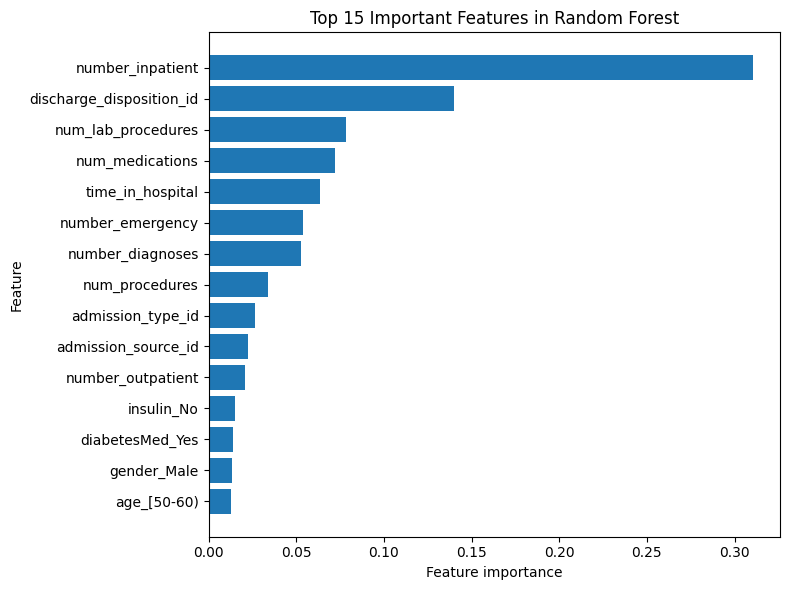

In [23]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features in Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#  Hyperparameter Tuning

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 10, 15, None],
    "min_samples_leaf": [10, 20, 50],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV ROC-AUC:")
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("\nBest Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nBest Random Forest Classification Report:")
print(classification_report(y_test, y_pred_best))

print("\nBest Random Forest Test ROC-AUC:")
print(roc_auc_score(y_test, y_prob_best))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
Best CV ROC-AUC:
0.6607494727982077

Best Random Forest Confusion Matrix:
[[13099  4299]
 [ 1204  1009]]

Best Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     17398
           1       0.19      0.46      0.27      2213

    accuracy                           0.72     19611
   macro avg       0.55      0.60      0.55     19611
weighted avg       0.83      0.72      0.76     19611


Best Random Forest Test ROC-AUC:
0.6559775401517862


I further improved the Random Forest model using GridSearchCV with 3-fold cross-validation. The tuning process evaluated 72 parameter combinations and selected a model with 300 trees, maximum depth of 15, minimum leaf size of 20, and square-root feature sampling. The tuned Random Forest achieved a test ROC-AUC of 0.656, slightly improving over the baseline Random Forest model. However, the recall for 30-day readmission was 0.46, indicating that many readmitted patients were still missed. This suggests that although hyperparameter tuning improved overall ranking performance, further work such as threshold adjustment, feature engineering, or resampling may be needed to improve minority-class detection.

#  Threshold Adjustment

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

threshold_results = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_threshold = (y_prob_best >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    accuracy = accuracy_score(y_test, y_pred_threshold)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df)

   threshold  accuracy  precision    recall  f1_score
0        0.2  0.121055   0.113501  0.996837  0.203797
1        0.3  0.232778   0.122225  0.938093  0.216273
2        0.4  0.489572   0.149195  0.749209  0.248837
3        0.5  0.719392   0.190090  0.455942  0.268315
4        0.6  0.855183   0.272661  0.169905  0.209354




Because the outcome was highly imbalanced, I evaluated multiple classification thresholds for the tuned Random Forest model. Lower thresholds substantially increased recall for 30-day readmission but reduced precision and overall accuracy.

At the default threshold of 0.5, the model achieved the highest F1-score of 0.268, with a precision of 0.190 and recall of 0.456 for the readmission class. When the threshold was lowered to 0.4, recall increased to 0.749, meaning the model identified about three-quarters of actual 30-day readmissions. However, precision decreased to 0.149, indicating more false positives.

In a healthcare screening setting, a lower threshold such as 0.4 may be preferred if the goal is to identify more high-risk patients for follow-up. In contrast, a higher threshold may be preferred when reducing false positives is more important.

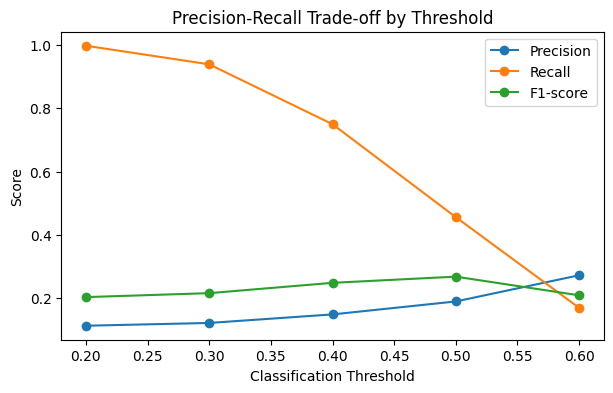

In [26]:
plt.figure(figsize=(7, 4))

plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1_score"], marker="o", label="F1-score")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold")
plt.legend()

plt.show()

#  Model Comparison

In [32]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "ROC_AUC": [
        0.632,
        0.653,
        0.656
    ],
    "Class_1_Precision": [
        0.17,
        0.18,
        0.19
    ],
    "Class_1_Recall": [
        0.49,
        0.55,
        0.46
    ],
    "Class_1_F1": [
        0.25,
        0.27,
        0.27
    ]
})

print(model_results)

                 Model  ROC_AUC  Class_1_Precision  Class_1_Recall  Class_1_F1
0  Logistic Regression    0.632               0.17            0.49        0.25
1        Random Forest    0.653               0.18            0.55        0.27
2  Tuned Random Forest    0.656               0.19            0.46        0.27


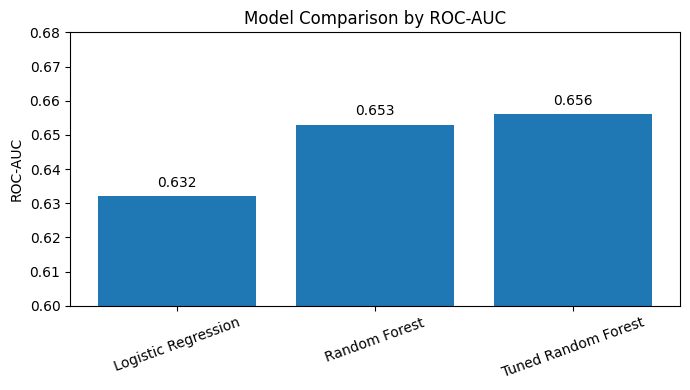

In [33]:
plt.figure(figsize=(7, 4))

bars = plt.bar(model_results["Model"], model_results["ROC_AUC"])

plt.ylabel("ROC-AUC")
plt.title("Model Comparison by ROC-AUC")
plt.ylim(0.60, 0.68)
plt.xticks(rotation=20)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

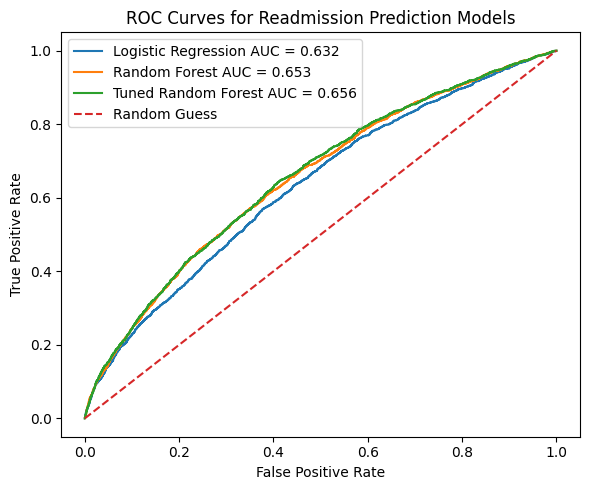

In [34]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")
plt.plot(fpr_best, tpr_best, label=f"Tuned Random Forest AUC = {auc_best:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Readmission Prediction Models")
plt.legend()
plt.tight_layout()
plt.show()

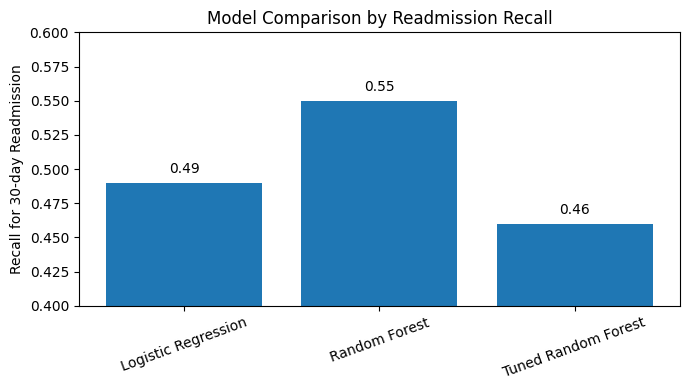

In [30]:
plt.figure(figsize=(7, 4))

bars = plt.bar(model_results["Model"], model_results["Class_1_Recall"])

plt.ylabel("Recall for 30-day Readmission")
plt.title("Model Comparison by Readmission Recall")
plt.ylim(0.40, 0.60)
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#  Conclusion

This project analyzed 98,053 hospital encounters among diabetic patients to study 30-day hospital readmission. After cleaning missing values and creating a binary outcome variable, exploratory analysis showed that only 11.29% of encounters resulted in 30-day readmission, indicating a strong class imbalance problem.

EDA results suggested that prior healthcare utilization and clinical complexity were associated with readmission risk. Patients with more prior inpatient visits had higher readmission rates, and patients prescribed diabetes medication or with a higher number of medications also showed higher readmission risk.

Three predictive models were evaluated: Logistic Regression, Random Forest, and Tuned Random Forest. The tuned Random Forest achieved the highest ROC-AUC of 0.656, showing modest discrimination ability. Feature importance analysis showed that prior inpatient visits, discharge disposition, number of lab procedures, number of medications, and time in hospital were among the most important predictors.

Because the outcome was imbalanced, threshold adjustment was also evaluated. Lowering the classification threshold to 0.4 increased recall to 0.749, allowing the model to identify about three-quarters of actual 30-day readmissions, although precision decreased. This trade-off may be acceptable in a healthcare screening setting where identifying high-risk patients is prioritized.

Overall, the project demonstrates a complete machine learning workflow, including data cleaning, exploratory analysis, feature encoding, model training, hyperparameter tuning, model evaluation, and interpretation.